# Project 01: Bayesian Learning and Posterior Prediction for Discrete Data

This notebook develops a small Bayesian modeling workflow for discrete outcomes. The goal is to show how prior information is updated after observing data and how posterior distributions can be used for prediction.

The notebook covers four components:

1. Bayesian updating with a finite parameter space.
2. Beta-Bernoulli inference for binary outcomes.
3. Gamma-Poisson inference for count outcomes.
4. Posterior predictive inference for PGA Tour scoring data.

The project emphasizes reproducibility, clean implementation, and interpretation of uncertainty.

## 0. Setup

The code below imports the required packages, creates folders for figures, and sets a random seed for reproducibility.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import beta as beta_dist
from scipy.stats import gamma, nbinom
from scipy.special import gammaln

# Reproducibility
RANDOM_SEED = 57 
rng = np.random.default_rng(RANDOM_SEED)

# Project paths
FIGURES_DIR = Path("figures")
DATA_DIR = Path("data")

FIGURES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Plot defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Bayesian Updating with a Finite Parameter Space

Suppose the parameter can take only three values, $\theta \in \{1,2,3\}$. We observe data $Y$, and we are given a likelihood $p(Y \mid \theta)$ and a prior distribution $p(\theta)$.

Bayes' rule gives

$$
p(\theta \mid Y)
=
\frac{p(Y \mid \theta)p(\theta)}{p(Y)},
$$

where the marginal likelihood is

$$
p(Y) = \sum_{\theta} p(Y \mid \theta)p(\theta).
$$

This example introduces the basic Bayesian idea: posterior beliefs are proportional to likelihood times prior.

In [7]:
theta_values = np.array([1, 2, 3])

likelihood = np.array([1/5, 1/10, 1/2])
prior = np.array([1/3, 1/3, 1/3])

unnormalized_posterior = likelihood * prior
marginal_likelihood = unnormalized_posterior.sum()
posterior = unnormalized_posterior / marginal_likelihood

posterior_mean = np.sum(theta_values * posterior)
mle = theta_values[np.argmax(likelihood)]

finite_parameter_results = pd.DataFrame({
    "theta": theta_values,
    "likelihood": likelihood,
    "prior": prior,
    "posterior": posterior,
})

finite_parameter_results

,theta,likelihood,prior,posterior
0,1,0.2,0.333333,0.250
1,2,0.1,0.333333,0.125
2,3,0.5,0.333333,0.625


In [9]:
print(f"Marginal likelihood p(Y): {marginal_likelihood:.4f}")
print(f"Posterior mean E[theta | Y]: {posterior_mean:.4f}")
print(f"Maximum likelihood estimate: {mle}")

Marginal likelihood p(Y): 0.2667
Posterior mean E[theta | Y]: 2.3750
Maximum likelihood estimate: 3


### Interpretation

The posterior puts the largest probability on $\theta = 3$, because that value has the highest likelihood. The posterior mean is smaller than the maximum likelihood estimate because it averages over the full posterior distribution instead of selecting a single most likely value.

## 2. Beta-Bernoulli Model

Now consider binary outcomes $y_t \in \{0,1\}$, modeled as Bernoulli trials:

$$
y_t \mid p \sim \text{Bernoulli}(p).
$$

If the prior is

$$
p \sim \text{Beta}(\alpha_1,\alpha_2),
$$

then the posterior is

$$
p \mid Y \sim \text{Beta}(\alpha_1 + s,\alpha_2 + T - s),
$$

where $s = \sum_{t=1}^T y_t$.

The posterior mean is

$$
E[p \mid Y] =
\frac{\alpha_1+s}{\alpha_1+\alpha_2+T}.
$$

The maximum likelihood estimator is

$$
\widehat p_{\text{MLE}} = \frac{s}{T}.
$$

The prior hyperparameters can be interpreted as pseudo-observations: $\alpha_1$ prior successes and $\alpha_2$ prior failures.

In [14]:
def beta_bernoulli_posterior_parameters(y, alpha_prior, beta_prior):
    """
    Compute posterior parameters for a Beta-Bernoulli model.

    Parameters
    ----------
    y : array-like
        Binary outcomes.
    alpha_prior : float
        Prior alpha parameter.
    beta_prior : float
        Prior beta parameter.

    Returns
    -------
    alpha_post : float
        Posterior alpha parameter.
    beta_post : float
        Posterior beta parameter.
    """
    y = np.asarray(y)
    successes = y.sum()
    trials = len(y)

    alpha_post = alpha_prior + successes
    beta_post = beta_prior + trials - successes

    return alpha_post, beta_post


def summarize_beta_bernoulli(y, alpha_prior, beta_prior):
    """
    Return a compact summary for a Beta-Bernoulli update.
    """
    y = np.asarray(y)
    alpha_post, beta_post = beta_bernoulli_posterior_parameters(
        y, alpha_prior, beta_prior
    )

    posterior_mean = alpha_post / (alpha_post + beta_post)
    mle = y.mean()

    return {
        "n": len(y),
        "successes": int(y.sum()),
        "prior": f"Beta({alpha_prior}, {beta_prior})",
        "posterior": f"Beta({int(alpha_post)}, {int(beta_post)})",
        "mle": mle,
        "posterior_mean": posterior_mean,
    }


def plot_beta_prior_posterior(
    y,
    alpha_prior,
    beta_prior,
    title,
    save_path=None,
):
    """
    Plot prior and posterior densities for a Beta-Bernoulli model.
    """
    x_grid = np.linspace(0.001, 0.999, 1000)

    alpha_post, beta_post = beta_bernoulli_posterior_parameters(
        y, alpha_prior, beta_prior
    )

    prior_density = beta_dist.pdf(x_grid, alpha_prior, beta_prior)
    posterior_density = beta_dist.pdf(x_grid, alpha_post, beta_post)

    plt.figure()
    plt.plot(
        x_grid,
        prior_density,
        linewidth=2,
        label=fr"Prior: Beta({alpha_prior}, {beta_prior})",
    )
    plt.plot(
        x_grid,
        posterior_density,
        linewidth=2,
        label=fr"Posterior: Beta({int(alpha_post)}, {int(beta_post)})",
    )

    plt.xlabel("Success probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

### 2.1 Observed Bernoulli sample

The observed data are

$$
Y = (1,1,0,0,0,1,1,0,0,0)'.
$$

There are $T=10$ observations and $s=4$ successes.

In [17]:
y_observed = np.array([1, 1, 0, 0, 0, 1, 1, 0, 0, 0])

pd.DataFrame([
    summarize_beta_bernoulli(y_observed, alpha_prior=1, beta_prior=1),
    summarize_beta_bernoulli(y_observed, alpha_prior=16, beta_prior=4),
])

,n,successes,prior,posterior,mle,posterior_mean
0,10,4,"Beta(1, 1)","Beta(5, 7)",0.4,0.416667
1,10,4,"Beta(16, 4)","Beta(20, 10)",0.4,0.666667


### 2.2 Uniform prior

The uniform prior is $\text{Beta}(1,1)$. It is flat over the interval $[0,1]$, so the posterior is mostly driven by the observed sample.

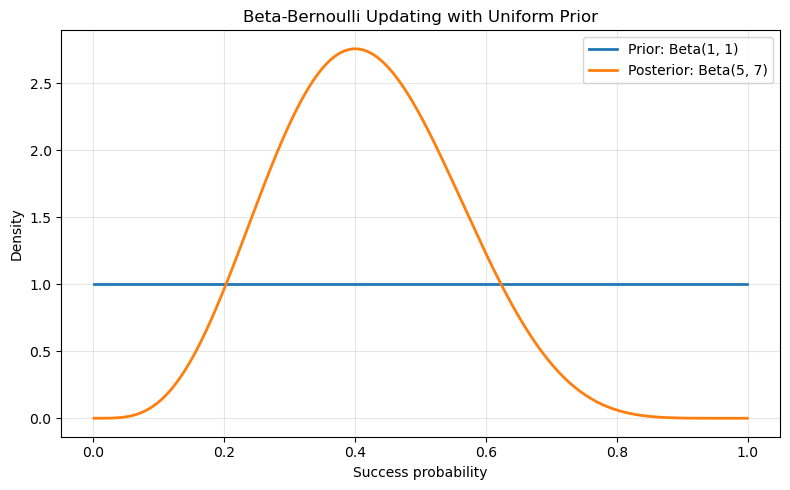

In [20]:
plot_beta_prior_posterior(
    y_observed,
    alpha_prior=1,
    beta_prior=1,
    title="Beta-Bernoulli Updating with Uniform Prior",
    save_path=FIGURES_DIR / "beta_uniform_prior_posterior.png",
)

### 2.3 Informative prior

The prior $\text{Beta}(16,4)$ is centered near $0.8$. Since the sample is small, the posterior remains strongly influenced by this prior.

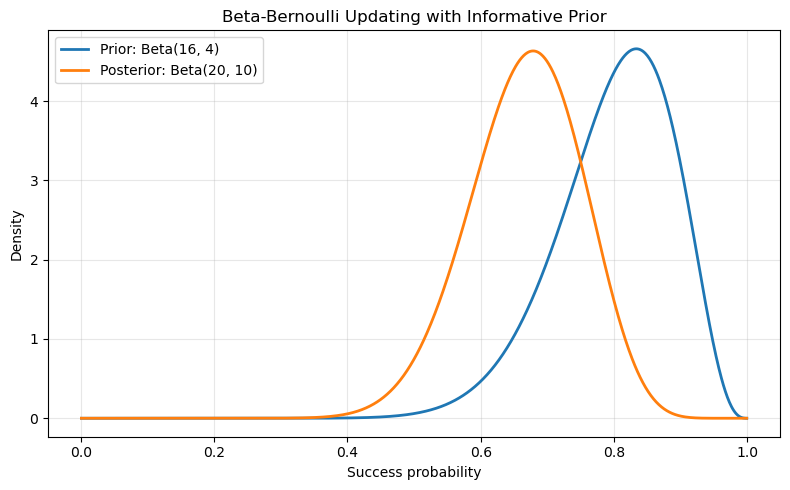

In [23]:
plot_beta_prior_posterior(
    y_observed,
    alpha_prior=16,
    beta_prior=4,
    title="Beta-Bernoulli Updating with Informative Prior",
    save_path=FIGURES_DIR / "beta_informative_prior_posterior.png",
)

### 2.4 Simulation: prior influence as sample size increases

To study Bayesian learning, simulate Bernoulli data with true success probability $p=0.25$. The prior remains $\text{Beta}(16,4)$, which is centered far away from the true value. As the sample size increases, the posterior moves toward the true data-generating value and becomes more concentrated.

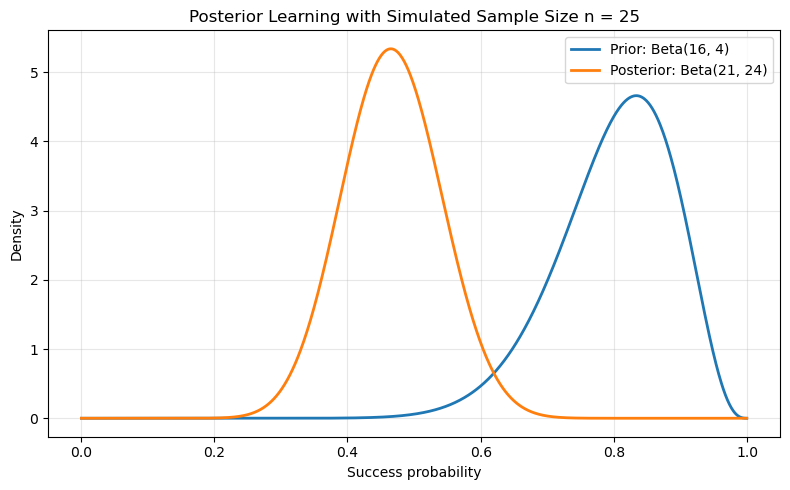

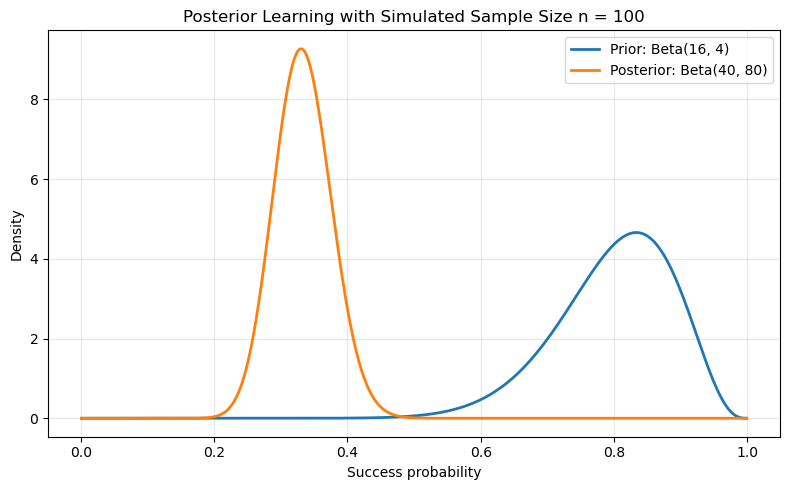

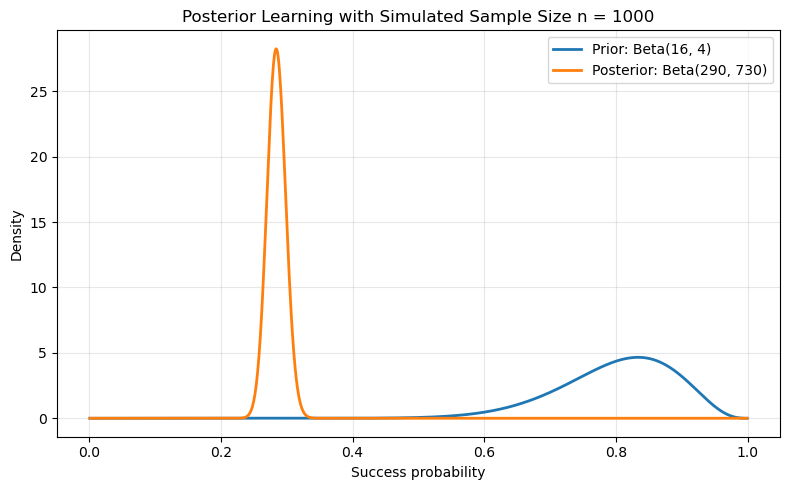

,n,successes,prior,posterior,mle,posterior_mean
0,25,5,"Beta(16, 4)","Beta(21, 24)",0.200,0.466667
1,100,24,"Beta(16, 4)","Beta(40, 80)",0.240,0.333333
2,1000,274,"Beta(16, 4)","Beta(290, 730)",0.274,0.284314


In [27]:
true_probability = 0.25
sample_sizes = [25, 100, 1000]

simulation_summaries = []

for n in sample_sizes:
    y_simulated = rng.binomial(n=1, p=true_probability, size=n)

    simulation_summaries.append(
        summarize_beta_bernoulli(
            y_simulated,
            alpha_prior=16,
            beta_prior=4,
        )
    )

    plot_beta_prior_posterior(
        y_simulated,
        alpha_prior=16,
        beta_prior=4,
        title=f"Posterior Learning with Simulated Sample Size n = {n}",
        save_path=FIGURES_DIR / f"beta_learning_n_{n}.png",
    )

pd.DataFrame(simulation_summaries)

### Beta-Bernoulli takeaway

With small samples, the posterior can be strongly affected by the prior. With larger samples, the likelihood dominates, and the posterior concentrates near the true probability. This is one of the main practical lessons of Bayesian updating.

## 3. Gamma-Poisson Model

Now consider count outcomes modeled as

$$
y_i \mid \lambda \sim \text{Poisson}(\lambda).
$$

For a sample $Y=(y_1,\ldots,y_N)$, the likelihood is

$$
p(Y \mid \lambda)
\propto
\lambda^s e^{-N\lambda},
\qquad
s = \sum_{i=1}^N y_i.
$$

Use a Gamma prior with shape-scale parameterization:

$$
\lambda \sim \text{Gamma}(\alpha,\beta),
$$

where

$$
E[\lambda] = \alpha\beta,
\qquad
\text{Var}(\lambda) = \alpha\beta^2.
$$

The posterior is

$$
\lambda \mid Y
\sim
\text{Gamma}\left(
\alpha+s,
\frac{\beta}{1+N\beta}
\right).
$$

The posterior mean is

$$
E[\lambda \mid Y]
=
(\alpha+s)\frac{\beta}{1+N\beta}.
$$

The maximum likelihood estimator is

$$
\widehat\lambda_{\text{MLE}} = \frac{s}{N}.
$$

The posterior predictive distribution for a future count $$y^*$$ is Negative Binomial.

In [30]:
def gamma_poisson_posterior_parameters(counts, alpha_prior, beta_prior):
    """
    Compute posterior parameters for a Gamma-Poisson model.

    The Gamma distribution is parameterized by shape alpha and scale beta.
    """
    counts = np.asarray(counts)
    n_obs = len(counts)
    total_count = counts.sum()

    alpha_post = alpha_prior + total_count
    beta_post = beta_prior / (1 + n_obs * beta_prior)

    return alpha_post, beta_post


def summarize_gamma_poisson(counts, alpha_prior, beta_prior):
    """
    Return summary quantities for a Gamma-Poisson update.
    """
    counts = np.asarray(counts)

    alpha_post, beta_post = gamma_poisson_posterior_parameters(
        counts, alpha_prior, beta_prior
    )

    prior_mean = alpha_prior * beta_prior
    prior_var = alpha_prior * beta_prior**2
    posterior_mean = alpha_post * beta_post
    posterior_var = alpha_post * beta_post**2
    mle = counts.mean()

    return {
        "n": len(counts),
        "sum_y": counts.sum(),
        "prior_mean": prior_mean,
        "prior_sd": np.sqrt(prior_var),
        "mle": mle,
        "posterior_mean": posterior_mean,
        "posterior_sd": np.sqrt(posterior_var),
        "alpha_post": alpha_post,
        "beta_post": beta_post,
    }

## 4. Empirical Application: Bayesian Prediction of PGA Scores

The empirical application models PGA Tour 18-hole scores as count data. The model is

$$
y_i \mid \lambda \sim \text{Poisson}(\lambda),
$$

where $\lambda$ is the average 18-hole score.

The prior is

$$
\lambda \sim \text{Gamma}(576,1/8).
$$

This prior has mean $72$ and standard deviation $3$, reflecting the belief that professional golf scores are usually near the low 70s.

### 4.1 Load the data

Place `pga_scores.xlsx` either in the same folder as this notebook or inside a `data/` folder.

In [36]:
def load_pga_scores():
    """
    Load PGA scores from pga_scores.xlsx.

    The original file stores the score variable in column D,
    which corresponds to index 3 in Python.
    """
    possible_paths = [
        Path("pga_scores.xlsx"),
        DATA_DIR / "pga_scores.xlsx",
    ]

    for path in possible_paths:
        if path.exists():
            file = pd.read_excel(path)
            scores = file.iloc[:, 3].dropna().astype(float)
            return scores

    raise FileNotFoundError(
        "Could not find pga_scores.xlsx. Place it in the notebook folder "
        "or in the data/ folder."
    )


scores = load_pga_scores()

pga_summary = pd.Series({
    "N": len(scores),
    "Mean": scores.mean(),
    "Standard deviation": scores.std(),
    "Variance": scores.var(),
    "Minimum": scores.min(),
    "Maximum": scores.max(),
})

pga_summary

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


N                     7577.000000
Mean                    71.223703
Standard deviation       3.198671
Variance                10.231497
Minimum                 61.000000
Maximum                 87.000000
dtype: float64

### 4.2 Prior choice

The Gamma prior is chosen to be centered around a plausible PGA scoring average:

$$
E[\lambda] = \alpha\beta = 576 \times \frac18 = 72,
$$

with variance

$$
\text{Var}(\lambda) = \alpha\beta^2 = 9.
$$

Thus the prior standard deviation is $3$.

In [39]:
alpha_prior = 576
beta_prior = 1 / 8

prior_mean = alpha_prior * beta_prior
prior_var = alpha_prior * beta_prior**2
prior_sd = np.sqrt(prior_var)

pd.Series({
    "alpha_prior": alpha_prior,
    "beta_prior": beta_prior,
    "prior_mean": prior_mean,
    "prior_variance": prior_var,
    "prior_standard_deviation": prior_sd,
})

alpha_prior                 576.000
beta_prior                    0.125
prior_mean                   72.000
prior_variance                9.000
prior_standard_deviation      3.000
dtype: float64

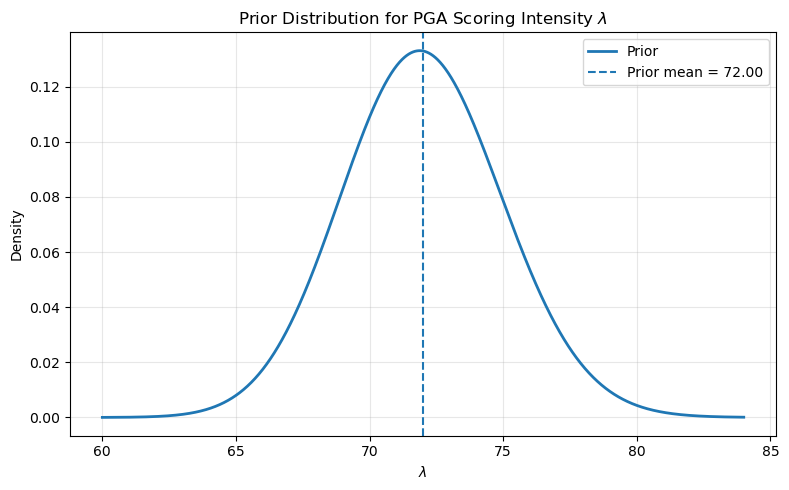

In [41]:
lambda_grid = np.linspace(60, 84, 2000)
prior_density = gamma.pdf(lambda_grid, a=alpha_prior, scale=beta_prior)

plt.figure()
plt.plot(lambda_grid, prior_density, linewidth=2, label="Prior")
plt.axvline(
    prior_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Prior mean = {prior_mean:.2f}",
)

plt.xlabel(r"$\lambda$")
plt.ylabel("Density")
plt.title(r"Prior Distribution for PGA Scoring Intensity $\lambda$")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gamma_prior_pga.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3 Posterior distribution

After observing the data, the posterior is

$$
\lambda \mid Y
\sim
\text{Gamma}\left(
576+\sum_i y_i,
\frac{1/8}{1+N/8}
\right).
$$

Because the sample size is large, the posterior becomes highly concentrated near the empirical average score.

In [44]:
gamma_poisson_summary = summarize_gamma_poisson(
    scores,
    alpha_prior=alpha_prior,
    beta_prior=beta_prior,
)

pd.Series(gamma_poisson_summary)

n                   7577.000000
sum_y             539662.000000
prior_mean            72.000000
prior_sd               3.000000
mle                   71.223703
posterior_mean        71.224522
posterior_sd           0.096903
alpha_post        540238.000000
beta_post              0.000132
dtype: float64

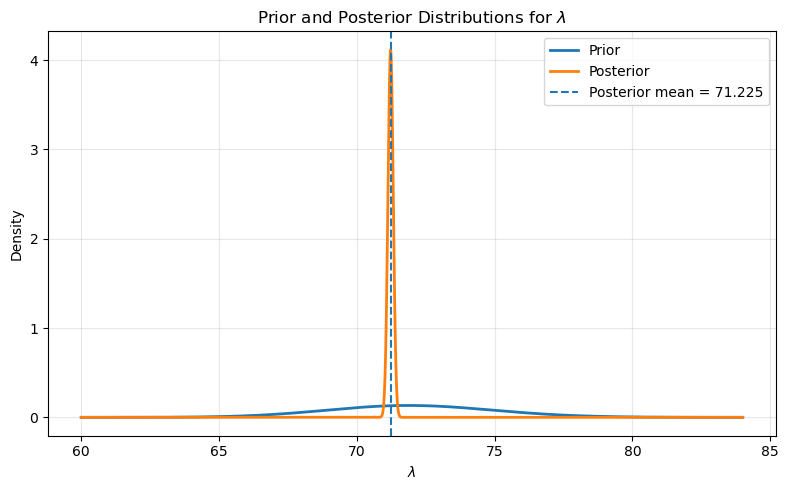

In [46]:
alpha_post = gamma_poisson_summary["alpha_post"]
beta_post = gamma_poisson_summary["beta_post"]
post_mean = gamma_poisson_summary["posterior_mean"]
post_sd = gamma_poisson_summary["posterior_sd"]

lambda_grid = np.linspace(60, 84, 2000)

prior_density = gamma.pdf(lambda_grid, a=alpha_prior, scale=beta_prior)
posterior_density = gamma.pdf(lambda_grid, a=alpha_post, scale=beta_post)

plt.figure()
plt.plot(lambda_grid, prior_density, linewidth=2, label="Prior")
plt.plot(lambda_grid, posterior_density, linewidth=2, label="Posterior")
plt.axvline(
    post_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Posterior mean = {post_mean:.3f}",
)

plt.xlabel(r"$\lambda$")
plt.ylabel("Density")
plt.title(r"Prior and Posterior Distributions for $\lambda$")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gamma_prior_posterior_pga.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.4 Posterior predictive distribution

The posterior predictive distribution integrates over uncertainty in $\lambda$:

$$
p(y^* \mid Y)
=
\int p(y^* \mid \lambda)p(\lambda \mid Y)d\lambda.
$$

For the Gamma-Poisson model, this distribution is Negative Binomial.

Using SciPy's parameterization,

$$
Y^* \sim \text{NegBinom}(n,p),
$$

where

$$
n = \alpha_{\text{post}},
\qquad
p = \frac{1}{1+\beta_{\text{post}}}.
$$

In [49]:
n_pred = alpha_post
p_pred = 1 / (1 + beta_post)

pred_mean = nbinom.mean(n_pred, p_pred)
pred_mode = int(np.floor((n_pred - 1) * (1 - p_pred) / p_pred))

prob_above_75 = nbinom.sf(75, n_pred, p_pred)
prob_65_70 = nbinom.cdf(70, n_pred, p_pred) - nbinom.cdf(64, n_pred, p_pred)

posterior_predictive_summary = pd.Series({
    "Posterior predictive mean": pred_mean,
    "Posterior predictive mode": pred_mode,
    "P(score > 75)": prob_above_75,
    "P(65 <= score <= 70)": prob_65_70,
})

posterior_predictive_summary

Posterior predictive mean    71.224522
Posterior predictive mode    71.000000
P(score > 75)                 0.301108
P(65 <= score <= 70)          0.258766
dtype: float64

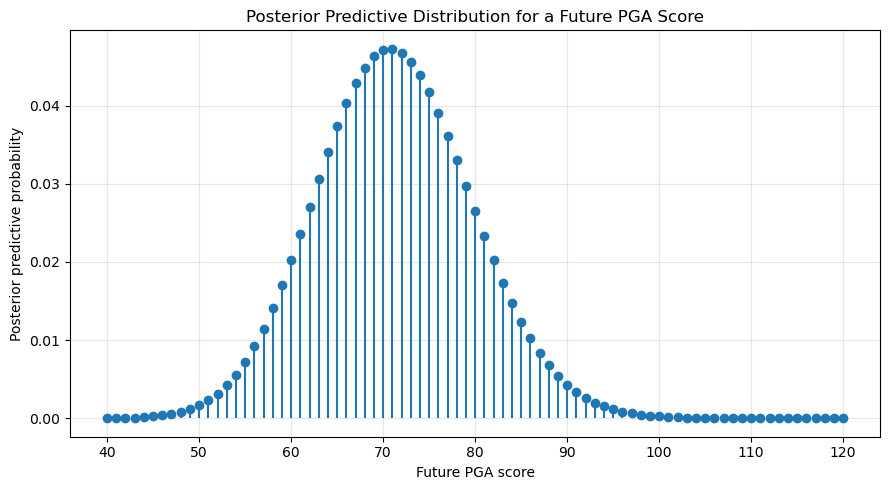

In [51]:
score_grid = np.arange(40, 121)
posterior_predictive_pmf = nbinom.pmf(score_grid, n_pred, p_pred)

plt.figure(figsize=(9, 5))
plt.stem(score_grid, posterior_predictive_pmf, basefmt=" ")

plt.xlabel("Future PGA score")
plt.ylabel("Posterior predictive probability")
plt.title("Posterior Predictive Distribution for a Future PGA Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "posterior_predictive_pga.png", dpi=300, bbox_inches="tight")
plt.show()

### PGA application takeaway

The posterior predictive distribution transforms parameter uncertainty into direct statements about future scores. Instead of reporting only a fitted mean, the model gives probabilities for practically meaningful scoring events, such as the probability of a future score above 75 or within the range 65 to 70.

This is the core value of Bayesian predictive modeling: it produces interpretable uncertainty statements that can be used for decision-making.

## 5. Project Takeaways

This project demonstrates a complete Bayesian workflow for discrete data:

- Specify a likelihood for the data.
- Choose a prior distribution.
- Derive the posterior distribution.
- Compare Bayesian estimates with maximum likelihood estimates.
- Visualize prior and posterior uncertainty.
- Compute posterior predictive probabilities.
- Interpret the model in an applied setting.

The Bernoulli examples show how priors interact with sample size. The PGA application shows how the Gamma-Poisson model can be used for posterior prediction in a real dataset.

## 6. Possible Extensions

Natural extensions of this project include:

1. Comparing different priors for the PGA scoring model.
2. Using a hierarchical model to allow player-specific scoring rates.
3. Modeling scores with an alternative distribution that allows more flexible variance.
4. Adding covariates such as course difficulty, tournament, weather, or player skill.
5. Evaluating out-of-sample predictive accuracy.